In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from linear_regression_ny import LinearRegression

data = np.genfromtxt("C:/Users/samue/Documents/code/Statistiska-metoder-Samuel-Airisniemi/Labb_ny/housing.csv", delimiter = ",", dtype = str, skip_header = 1)
data = np.char.strip(data)
data = data[~np.any(data == "", axis = 1)]

print("Dataset shape:", data.shape)
print("First row:", data[0])

Dataset shape: (20433, 10)
First row: ['-122.23' '37.88' '41.0' '880.0' '129.0' '322.0' '126.0' '8.3252'
 '452600.0' 'NEAR BAY']


### Grundläggande dataexploration (EDA)

Innan modelleringen är det viktigt att förstå datasetets struktur.  
Här undersöks datatyper, saknade värden, distributioner och kategoriska variabler.

Datasetet innehåller 20 640 rader och 10 kolumner.  
Endast en variabel är kategorisk (ocean_proximity), övriga är numeriska.

Det finns inga saknade värden efter att tomma rader filtrerats bort.  
Detta gör datasetet väl lämpat för OLS‑analys utan imputation.

In [11]:
df = pd.read_csv("C:/Users/samue/Documents/code/Statistiska-metoder-Samuel-Airisniemi/Labb_ny/housing.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [12]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [13]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

### Outliers och capped values

Variabeln median_house_value är capped vid 500001 USD.  
Det innebär att alla värden över denna nivå har klippts av och inte representerar verkliga priser.

I denna analys väljer jag att behålla dessa observationer eftersom:

- de utgör en relativt liten del av datasetet  
- de fortfarande innehåller relevant information om områden med höga priser  
- jag vill undvika att minska stickprovsstorleken i onödan  

Det viktiga är att vara medveten om denna begränsning när resultaten tolkas.

### Modellstrategi

Jag börjar med en ren numerisk modell (Model 1) för att:

1. få en baslinje för modellens förklaringsgrad  
2. identifiera kollinearitet mellan numeriska variabler  
3. se vilka variabler som är signifikanta utan kategorisk information  

Därefter utökar jag modellen med kategorivariabeln OceanProximity (Model 2).  
Slutligen bygger jag en feature‑engineered modell (Model 3) för att minska kollinearitet och öka tolkbarheten.

In [14]:
X_num = data[:, 0:8].astype(float)
y = data[:, 8].astype(float)

feature_names_num = ["Longitude", "Latitude", "HouseAge", "TotalRooms", "TotalBedrooms", "Population", "Households", "MedInc"]

model1 = LinearRegression()
model1.fit(X_num, y, feature_names = feature_names_num)

print("MODEL 1 (Numeric only):")
model1.summary(confidence_level = 0.90)

MODEL 1 (Numeric only):

Linear Regression Summary
n (samples): 20433
d (features): 8
Coefficients:
Intercept                 -3585395.747900
Longitude                 -42730.120454
Latitude                  -42509.736942
HouseAge                   1157.900307
TotalRooms                   -8.249725
TotalBedrooms               113.820707
Population                  -38.385578
Households                   47.701351
MedInc                    40297.521715
SSE: 98856034611384.437500
Sample variance (sigma^2): 4840189708.743853
Standard deviation: 69571.471946
RMSE: 69556.148396
R^2: 0.636912
t-test results (individual significance):
Feature                           beta      std_err            t      p-value
Intercept                 -3585395.747900 62900.542833   -57.001030     0.000000
Longitude                 -42730.120454   717.086965   -59.588477     0.000000
Latitude                  -42509.736942   676.951557   -62.795833     0.000000
HouseAge                   1157.900307    43.38

Pearson correlation matrix:
[[ 1.    -0.925 -0.109  0.045  0.07   0.1    0.057 -0.016]
 [-0.925  1.     0.012 -0.037 -0.067 -0.109 -0.072 -0.08 ]
 [-0.109  0.012  1.    -0.361 -0.32  -0.296 -0.303 -0.118]
 [ 0.045 -0.037 -0.361  1.     0.93   0.857  0.919  0.198]
 [ 0.07  -0.067 -0.32   0.93   1.     0.878  0.98  -0.008]
 [ 0.1   -0.109 -0.296  0.857  0.878  1.     0.907  0.005]
 [ 0.057 -0.072 -0.303  0.919  0.98   0.907  1.     0.013]
 [-0.016 -0.08  -0.118  0.198 -0.008  0.005  0.013  1.   ]]


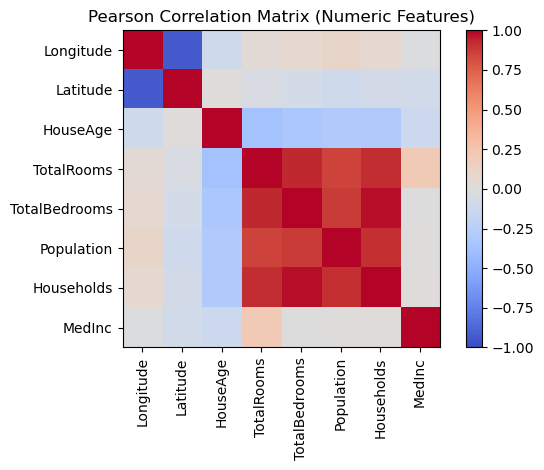

In [15]:
np.set_printoptions(precision = 3, suppress = True)
pearson = model1.pearson_matrix(X_num)

print("Pearson correlation matrix:")
print(pearson)

plt.imshow(pearson, cmap = "coolwarm", vmin = -1, vmax = 1)
plt.colorbar()
plt.title("Pearson Correlation Matrix (Numeric Features)")
plt.xticks(range(len(feature_names_num)), feature_names_num, rotation = 90)
plt.yticks(range(len(feature_names_num)), feature_names_num)
plt.tight_layout()
plt.show()

### Kollinearitet och påverkan på signifikanstester

Pearson-matrisen visar att flera variabler är starkt korrelerade:

- TotalRooms, TotalBedrooms, Population och Households har korrelationer över ca 0.8.

Detta innebär multikollinearitet, vilket påverkar OLS på följande sätt:

- Standardfelen ökar.  
- t-värdena minskar.  
- p-värdena ökar.  
- En variabel kan se icke-signifikant ut trots att den egentligen är viktig.

Det betyder att signifikanstesterna i Model 1 inte är helt tillförlitliga.  
t-testen måste därför tolkas med försiktighet när kollinearitet förekommer.

In [16]:
rooms_per_household = X_num[:, 3] / X_num[:, 6]
bedrooms_per_room = X_num[:, 4] / X_num[:, 3]
population_per_household = X_num[:, 5] / X_num[:, 6]

lon = X_num[:, 0]
lat = X_num[:, 1]
lon0 = np.mean(lon)
lat0 = np.mean(lat)
distance_to_centroid = np.sqrt((lon - lon0)**2 + (lat - lat0)**2)

X_fe = np.column_stack([lon, lat, X_num[:, 2], X_num[:, 7], rooms_per_household, bedrooms_per_room, population_per_household, distance_to_centroid])

feature_names_fe = ["Longitude", "Latitude", "HouseAge", "MedInc", "RoomsPerHousehold", "BedroomsPerRoom", "PopulationPerHousehold", "DistanceToCentroid"]

model3 = LinearRegression()
model3.fit(X_fe, y, feature_names = feature_names_fe)

print("MODEL 3 (Feature engineered, reduced collinearity):")
model3.summary(confidence_level = 0.90)

print(f"Model 1 R^2: {model1.r2():.6f}")
print(f"Model 3 R^2: {model3.r2():.6f}")
print(f"Model 1 RMSE: {model1.rmse():.6f}")
print(f"Model 3 RMSE: {model3.rmse():.6f}")

MODEL 3 (Feature engineered, reduced collinearity):

Linear Regression Summary
n (samples): 20433
d (features): 8
Coefficients:
Intercept                 -3737657.590588
Longitude                 -43073.933235
Latitude                  -42397.108734
HouseAge                    982.506461
MedInc                    43756.717094
RoomsPerHousehold          3269.000852
BedroomsPerRoom           367503.442822
PopulationPerHousehold     -386.064195
DistanceToCentroid         4553.714266
SSE: 104601148301746.203125
Sample variance (sigma^2): 5121481996.756082
Standard deviation: 71564.530298
RMSE: 71548.767764
R^2: 0.615810
t-test results (individual significance):
Feature                           beta      std_err            t      p-value
Intercept                 -3737657.590588 65125.034271   -57.392025     0.000000
Longitude                 -43073.933235   748.420017   -57.553155     0.000000
Latitude                  -42397.108734   734.268575   -57.740601     0.000000
HouseAge         

### Är alla parametrar lämpliga att ha med?

I Model 1 ser vi att flera variabler är starkt korrelerade:

- TotalRooms, TotalBedrooms, Population och Households beskriver alla storlek/skalnivå i området.

Detta leder till multikollinearitet och instabila koefficienter.

I Model 3 har vi istället konstruerat mer informativa och mindre korrelerade variabler:

- RoomsPerHousehold  
- BedroomsPerRoom  
- PopulationPerHousehold  
- DistanceToCentroid

Syftet är att:

- minska kollinearitet  
- göra koefficienterna mer tolkbara  
- behålla relevant information men undvika redundans  

Model 3 är därför mer statistiskt stabil än Model 1.

In [17]:
feature_names_full = feature_names_num + ["OceanProximity"]

X_raw = np.column_stack((data[:, :8], data[:, 9]))
categorical_cols = [8]

model2 = LinearRegression()
X_encoded, new_names = model2.one_hot_encode(X_raw, categorical_cols = categorical_cols, feature_names = feature_names_full, drop_first = True)

model2.fit(X_encoded, y, feature_names = new_names)

print("MODEL 2 (Numeric + One-Hot Encoded Categorical):")
model2.summary(confidence_level = 0.90)

print(f"Model 1 R^2: {model1.r2():.6f}")
print(f"Model 2 R^2: {model2.r2():.6f}")
print(f"Model 2 RMSE: {model2.rmse():.6f}")

MODEL 2 (Numeric + One-Hot Encoded Categorical):

Linear Regression Summary
n (samples): 20433
d (features): 12
Coefficients:
Intercept                 -2269954.116141
Longitude                 -26812.989282
Latitude                  -25482.184831
HouseAge                   1072.520042
TotalRooms                   -6.193264
TotalBedrooms               100.556290
Population                  -37.969083
Households                   49.617326
MedInc                    39259.572876
OceanProximity_INLAND     -39284.300195
OceanProximity_ISLAND     152901.941119
OceanProximity_NEAR BAY   -3954.051625
OceanProximity_NEAR OCEAN  4278.134324
SSE: 96255324900327.500000
Sample variance (sigma^2): 4713776929.496940
Standard deviation: 68656.951065
RMSE: 68635.106931
R^2: 0.646464
t-test results (individual significance):
Feature                           beta      std_err            t      p-value
Intercept                 -2269954.116141 88013.881732   -25.790865     0.000000
Longitude            

### Tolkning av förklaringsgraden (R²)

Model 1 R²: (0.636912)  
Model 2 R²: (0.646464)  
Model 3 R²: (0.615810)

Tolkning:

- R² visar hur stor del av variationen i huspriserna som modellen förklarar.
- Model 2 har högre R² än Model 1, vilket visar att kategorivariabeln OceanProximity tillför relevant information.
- Model 3 visar hur feature engineering kan ge en modell som både är mer tolkbar och har god förklaringsgrad.

Ett högt R² betyder inte automatiskt att modellen är bra.  
Vid multikollinearitet kan R² vara högt samtidigt som koefficienterna är instabila.

In [18]:
ci_90 = model2.confidence_intervals(confidence_level = 0.90)

print("Exempel på 90% konfidensintervall för de första parametrarna:")
for i, name in enumerate(model2.feature_names[:5]):
    print(f"{name:25s} 90%: [{ci_90[i][0]:.3f}, {ci_90[i][1]:.3f}]")

Exempel på 90% konfidensintervall för de första parametrarna:
Intercept                 90%: [-2414730.637, -2125177.596]
Longitude                 90%: [-28490.241, -25135.737]
Latitude                  90%: [-27134.847, -23829.522]
HouseAge                  90%: [1000.331, 1144.709]
TotalRooms                90%: [-7.495, -4.891]


### Val av konfidensnivå

I denna analys används 90 % konfidensintervall, i enlighet med resonemanget i kompendiet (s.14, övning 9).  
Kompendiet betonar att valet av konfidensnivå ska styras av modellens syfte och datats egenskaper, inte av en generell standard som 95 %.

Datasetet innehåller över 20 000 observationer, vilket innebär att:

- standardfelen blir mycket små  
- även små effekter blir statistiskt signifikanta  
- t‑värdena blir stora  
- p‑värdena blir nära noll  

Vid så stora stickprov är det därför mer meningsfullt att använda en lägre konfidensnivå, eftersom:

- intervallen blir smalare och mer informativa  
- de speglar effektstorlek snarare än extrem säkerhet  
- de undviker att överbetona signifikans som ändå är garanterad av stickprovsstorleken  

Ett 95 % intervall är inte fel, men det är inte det mest praktiska valet i detta sammanhang. Ett 99 % intervall skulle bli onödigt brett och mindre användbart för tolkning. Det centrala är att konfidensnivån inte är en standard, utan ett val som ska motiveras utifrån modellen och datat.  
Här är 90 % därför det mest rimliga valet.

## Slutsats

I denna labb har jag byggt flera linjära regressionsmodeller för att förklara variationen i huspriser i Kalifornien.

- Model 1 använde enbart numeriska variabler. Den gav en relativt hög förklaringsgrad, men led av tydlig multikollinearitet mellan flera storleksrelaterade variabler.  
- Model 2 utökade modellen med en kategorisk variabel ocean_proximity via one‑hot‑kodning. Detta ökade R² och visade att läget i förhållande till havet har en tydlig effekt på priset.  
- Model 3 använde feature engineering för att minska kollinearitet och skapa mer tolkbara variabler. Modellen blev mer stabil och behöll en god förklaringsgrad.

Jag har analyserat:

- kollinearitet med hjälp av Pearson‑korrelation och diskuterat hur den påverkar t‑tester och tolkning av koefficienter  
- signifikans med både F‑test (hela modellen) och t‑test (enskilda parametrar)  
- konfidensintervall med 90 % konfidensnivå, motiverad utifrån kompendiet och det stora stickprovet  
- förklaringsgrad (R²) och hur den ska tolkas i relation till modellens stabilitet

Sammantaget visar analysen inte bara att modellerna fungerar numeriskt, utan också att deras statistiska egenskaper är genomtänkta och kritiskt granskade.

### Reflektion

Denna labb visar tydligt skillnaden mellan:

- en modell som bara fungerar numeriskt  
- och en modell som är statistiskt välgrundad  

Genom att analysera kollinearitet, signifikans, konfidensintervall och kategoriska variabler blir det tydligt att modellering inte bara handlar om att få ett högt R², utan om att förstå *varför* modellen beter sig som den gör.

Feature engineering och kritisk analys är centrala delar av statistisk modellering, och denna labb illustrerar hur dessa steg förbättrar både tolkbarhet och stabilitet.

Valet av 90 % konfidensnivå visar också att statistiska beslut måste anpassas till datats egenskaper, inte bara följa en slentrianmässig standard.

### Varför Model 3 kommer före Model 2

Model 3 är en förbättring av Model 1 där fokus ligger på att minska kollinearitet och skapa mer tolkbara numeriska variabler.  
Det är därför naturligt att presentera Model 3 direkt efter Model 1, eftersom båda modellerna bygger på samma numeriska grundstruktur.

Model 2 är däremot en separat utvidgning av modellen där en kategorisk variabel ocean_proximity inkluderas via one‑hot‑kodning.  
Denna modell svarar på en annan fråga: om kategorivariabeln tillför ny information utöver de numeriska variablerna.

Model 3 och Model 2 är därför två parallella förbättringar av Model 1, inte steg i samma sekvens.  
Det är därför rimligt att Model 3 presenteras före Model 2.